In [2]:
# import the necessary libraries and functions
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print(os.getcwd())

/Users/petrospolydorou/thesis/Documents/projectaria_sandbox/projectaria_tools/projects/AriaDigitalTwinDatasetTools/object_anticipation/adt


In [4]:
# define the filepath
file_path = os.path.join('data', 'results', 'llm_predictions_results.csv')

# prints
print(file_path)

# load the dataframe
df_d = pd.read_csv(file_path)

# show
df_d.head()

data/results/llm_predictions_results.csv


,sequence,time,dot_value,distance_value,dot_counts,distance_counts,model_overall_accuracy,precision,recall,llm_activation_sensitivity,llm_interaction_accuracy,Tp,Fp,Fp_out,Fp_in,Fn,Total_ground_truths,Total_llm_predictions,Total_llm_activations,Total_correspondances
0,Apartment_release_work_seq107_M1292,2,0.7,1.5,15,15,0.188,0.188,0.500,0.375,0.5,3,13,10,3,0,6,16,15,6
1,Apartment_release_work_seq107_M1292,2,0.7,1.5,15,30,0.188,0.188,0.500,0.375,0.5,3,13,10,3,0,6,16,15,6
2,Apartment_release_work_seq107_M1292,2,0.7,1.5,15,45,0.059,0.062,0.167,0.312,0.2,1,15,11,4,1,6,16,15,5
3,Apartment_release_work_seq107_M1292,2,0.7,1.5,15,60,0.133,0.143,0.333,0.357,0.4,2,12,9,3,1,6,14,13,5
4,Apartment_release_work_seq107_M1292,2,0.7,1.5,15,75,0.071,0.077,0.167,0.385,0.2,1,12,8,4,1,6,13,12,5


In [5]:
# the parameters that I have 
print("Below are the unique combinations of the parameters")

# prints 
print(f"The unique values of the dot counts are:",      df_d['sequence'].unique())
print(f"The unique values of the dot counts are:",      df_d['dot_counts'].unique())
print(f"The unique values of the distance counts are:", df_d['distance_counts'].unique())
print(f"The unique values of the dot values are:",      df_d['dot_value'].unique())
print(f"The unique values of the distance values are:", df_d['distance_value'].unique())
print(f"the unique values of the time are:",            df_d['time'].unique())

Below are the unique combinations of the parameters
The unique values of the dot counts are: ['Apartment_release_work_seq107_M1292'
 'Apartment_release_work_seq109_M1292'
 'Apartment_release_meal_seq131_M1292'
 'Apartment_release_meal_seq147_M1292'
 'Apartment_release_clean_seq133_M1292'
 'Apartment_release_clean_seq137_M1292'
 'Apartment_release_clean_seq142_M1292'
 'Apartment_release_clean_seq150_M1292']
The unique values of the dot counts are: [15 30 45 60 75 90]
The unique values of the distance counts are: [15 30 45 60 75 90]
The unique values of the dot values are: [0.7 0.8 0.9]
The unique values of the distance values are: [1.5 2.  2.5]
the unique values of the time are: [2]


In [6]:
# the parameters that I have 
print("Below are the unique outcomes")
print('_')
print(f"The unique values of model accuarcy are:")
print(df_d['model_overall_accuracy'].unique())
print('_')
print(f"The unique values of precision are:", df_d['precision'].unique())
print('_')
print(f"The unique values of recall are:", df_d['recall'].unique())
print('_')
print(f"The unique values of llm activation sensitivity are:", df_d['llm_activation_sensitivity'].unique())
print('_')
print(f"the unique values of llm interaction accuracy are:", df_d['llm_interaction_accuracy'].unique())
print('_')

Below are the unique outcomes
_
The unique values of model accuarcy are:
[0.188 0.059 0.133 0.071 0.083 0.2   0.062 0.143 0.077 0.154 0.1   0.167
 0.091 0.182 0.    0.15  0.158 0.125 0.067 0.222 0.095 0.105 0.048 0.05
 0.118 0.231 0.111 0.214 0.211 0.176 0.053 0.056 0.136 0.13  0.174 0.25
 0.286 0.273 0.042 0.043 0.045 0.087 0.037 0.08  0.04  0.115 0.069 0.074
 0.12  0.107 0.034 0.038 0.208 0.19  0.103 0.16  0.148 0.129 0.097 0.138
 0.094 0.185 0.031 0.065 0.172 0.192 0.292 0.261 0.217 0.207 0.24  0.227
 0.241 0.179 0.033 0.061 0.03  0.036 0.121 0.238 0.368 0.278 0.389 0.235
 0.318 0.3   0.316 0.333 0.269 0.294 0.28  0.353 0.35  0.412 0.304 0.267
 0.263]
_
The unique values of precision are: [0.188 0.062 0.143 0.077 0.091 0.2   0.067 0.167 0.083 0.111 0.1   0.
 0.15  0.158 0.059 0.125 0.133 0.071 0.222 0.154 0.095 0.105 0.048 0.05
 0.118 0.231 0.182 0.214 0.333 0.211 0.176 0.3   0.286 0.267 0.25  0.5
 0.056 0.273 0.13  0.042 0.136 0.043 0.053 0.045 0.087 0.308 0.444 0.375
 0.385 0.364 

In [7]:
# Sequence - dataframes
sequence_dataframes_dict = {seq: df_d[df_d['sequence'] == seq].drop(df_d.columns[0], axis=1) for seq in df_d['sequence'].unique()}
sequence_dataframes_list = [df_d[df_d['sequence'] == seq].drop(df_d.columns[0], axis=1).reset_index() for seq in df_d['sequence'].unique()]
df_d = sequence_dataframes_dict['Apartment_release_clean_seq150_M1292']

In [10]:
# Assuming your DataFrame is named 'df'

# List of metrics for which you want to find the best parameter combinations
metrics = [
    'model_overall_accuracy', 
    'precision', 
    'recall', 
    'llm_activation_sensitivity', 
    'llm_interaction_accuracy',
    'Tp', 
    'Fp', 
    'Fp_out', 
    'Fp_in', 
    'Fn'
]

# List of parameter columns
parameter_columns = ['dot_value', 'distance_value', 'dot_counts', 'distance_counts']

# For each metric, find the maximum value and the corresponding parameter combinations
# for metric in metrics:
#     max_value = df_d[metric].max()
#     best_rows = df_d[df_d[metric] == max_value]
#     print(f"Best combinations for '{metric}' (maximum value {max_value}):\n")
#     display_columns = parameter_columns + [metric]
#     display_df = best_rows[display_columns].reset_index(drop=True)
#     print(display_df)
#     print("\n" + "-"*80 + "\n")

best_combinations = {}

for metric in metrics:
    max_value = df_d[metric].max()
    best_rows = df_d[df_d[metric] == max_value]
    best_combinations[metric] = best_rows[parameter_columns + [metric]].reset_index(drop=True)

# Now, best_combinations is a dictionary where each key is a metric, and the value is a DataFrame.
print(best_combinations['precision'])



   dot_value  distance_value  dot_counts  distance_counts  precision
0        0.8             2.0          75               45      0.467
1        0.8             2.0          75               60      0.467
2        0.8             2.5          75               75      0.467
3        0.9             2.0          75               45      0.467


In [12]:
# Assuming your DataFrame is named 'df'
# List of metrics for which you want to find the best parameter combinations
metrics = [
    'model_overall_accuracy', 
    'precision', 
    'recall', 
    'llm_activation_sensitivity', 
    'llm_interaction_accuracy',
    'Tp', 
]

false_outcomes = [
    'Fp', 
    'Fp_out', 
    'Fp_in', 
    'Fn'
]

# List of parameter columns
parameter_columns = ['time', 'dot_value', 'distance_value', 'dot_counts', 'distance_counts']

best_combinations = {}

for metric in metrics:
    max_value = df_d[metric].max()  # Ensure `df` is used if that is your main DataFrame
    best_rows = df_d[df_d[metric] == max_value]
    best_combinations[metric] = best_rows[parameter_columns + [metric]].reset_index(drop=True)
    best_combinations[metric].to_csv(f'parameters_best/The_best_parameter_combinations_{metric}.csv', index=False)

for false in false_outcomes:
    min_value = df_d[false].min()
    best_rows = df_d[df_d[false] == min_value]
    best_combinations[false] = best_rows[parameter_columns + [false]].reset_index(drop=True)
    best_combinations[false].to_csv(f'parameters_best/The_best_parameter_combinations_{false}.csv', index=False)

# Print the DataFrame for 'precision'
print(best_combinations['precision'])


   time  dot_value  distance_value  dot_counts  distance_counts  precision
0     2        0.8             2.0          75               45      0.467
1     2        0.8             2.0          75               60      0.467
2     2        0.8             2.5          75               75      0.467
3     2        0.9             2.0          75               45      0.467


In [41]:
# Assuming your DataFrame is named 'df_d'
# List of metrics for which you want to find the best parameter combinations
metrics = [
    'precision', 
    'recall', 
    'llm_interaction_accuracy',
    'llm_activation_sensitivity', 
    'Tp',
    'Fp_in',
    'Fp_out',
    'Fn',
    'model_overall_accuracy'
]
falses = [
    'Fp', 
    'Fp_out', 
    'Fp_in', 
    'Fn'
]

# List of parameter columns
parameter_columns = ['time', 'dot_value', 'distance_value', 'dot_counts', 'distance_counts']

best_combinations_precision_accuracy = {}
best_combinations_recall_accuracy = {}
best_combinations_precision = {}
best_combinations_overall = {}
best_combinations_sensitivity ={}
best_combinations_accuracy = {}
best_combinations = {}  # Initialize the dictionary

# max_values 
max_precision = df_d[metrics[0]].max()  
max_recall = df_d[metrics[1]].max()
max_accuracy = df_d[metrics[2]].max()
max_sensitivity = df_d[metrics[3]].max()
max_overall = df_d[metrics[8]].max()

# Corrected filtering conditions with parentheses
best_rows_1 = df_d[(df_d[metrics[0]] == max_precision) & (df_d[metrics[2]] == max_accuracy)]
best_rows_2 = df_d[(df_d[metrics[1]] == max_recall)]
best_rows_3= df_d[(df_d[metrics[3]] == max_sensitivity)]
best_rows_4 = df_d[(df_d[metrics[2]] == max_accuracy)]
best_rows_5 = df_d[(df_d[metrics[0]] == max_precision)]
best_rows_6 = df_d[(df_d[metrics[8]] == max_overall)]

# Save results for precision and recall / for best llm_accuracy
best_combinations_precision_accuracy[metrics[2]] = best_rows_1[parameter_columns+[metrics[1]]+[metrics[3]]+[metrics[4]]+[metrics[5]]+[metrics[6]]+[metrics[7]]].reset_index(drop=True)
best_combinations_recall_accuracy[metrics[2]] = best_rows_2[parameter_columns+[metrics[0]]+[metrics[2]]+[metrics[3]]+[metrics[4]]+[metrics[5]]+[metrics[6]]+[metrics[7]]].reset_index(drop=True)
best_combinations_sensitivity[metrics[3]] = best_rows_3[parameter_columns+[metrics[0]]+[metrics[1]]+[metrics[2]]+[metrics[4]]+[metrics[5]]+[metrics[6]]+[metrics[7]]].reset_index(drop=True)
best_combinations_accuracy[metrics[2]] = best_rows_4[parameter_columns+[metrics[0]]+[metrics[1]]+[metrics[3]]+[metrics[4]]+[metrics[5]]+[metrics[6]]+[metrics[7]]].reset_index(drop=True)
best_combinations_precision[metrics[0]] = best_rows_5[parameter_columns+[metrics[1]]+[metrics[2]]+[metrics[3]]+[metrics[4]]+[metrics[5]]+[metrics[6]]+[metrics[7]]].reset_index(drop=True)
best_combinations_overall[metrics[8]] = best_rows_6[parameter_columns+[metrics[0]]+[metrics[1]]+[metrics[2]]+[metrics[3]]+[metrics[4]]+[metrics[5]]+[metrics[6]]+[metrics[7]]].reset_index(drop=True)

# write to csv 
best_combinations_precision_accuracy[metrics[2]].to_csv(f'parameters_best/best_parameter_precision_accuracy_combinations_{metrics[2]}.csv', index=False)
best_combinations_recall_accuracy[metrics[2]].to_csv(f'parameters_best/best_parameter_recall_accuracy_combinations_{metrics[2]}.csv', index=False)
best_combinations_sensitivity[metrics[3]].to_csv(f'parameters_best/best_parameter_sensitivity_combinations_{metrics[3]}.csv', index=False)
best_combinations_accuracy[metrics[2]].to_csv(f'parameters_best/best_parameter_accuracy_combinations_{metrics[2]}.csv', index=False)
best_combinations_precision[metrics[0]].to_csv(f'parameters_best/best_parameter_precision_combinations_{metrics[0]}.csv', index=False)
best_combinations_overall[metrics[8]].to_csv(f'parameters_best/best_parameter_overall_combinations_{metrics[8]}.csv', index=False)

# Iterate over the 'falses' list to find the minimum value rows
for false in falses:
    min_value = df_d[false].min()
    best_rows = df_d[df_d[false] == min_value]
    best_combinations[false] = best_rows[parameter_columns + [false]].reset_index(drop=True)
    best_combinations[false].to_csv(f'parameters_best/The_best_parameter_combinations_{false}.csv', index=False)

# Print the DataFrame for 'precision' if it exists in `best_combinations`
if 'precision' in best_combinations:
    print(best_combinations['precision'])


In [13]:
df_d[(df_d['dot_value'] == 0.7) & (df_d['distance_value'] == 1.5) & (df_d['dot_counts'] == 15) & (df_d['distance_counts'] == 30)]


,time,dot_value,distance_value,dot_counts,distance_counts,model_overall_accuracy,precision,recall,llm_activation_sensitivity,llm_interaction_accuracy,Tp,Fp,Fp_out,Fp_in,Fn,Total_ground_truths,Total_llm_predictions,Total_llm_activations,Total_correspondances
2269,2,0.7,1.5,15,30,0.368,0.412,0.778,0.412,1.0,7,10,10,0,2,8,17,16,7


In [25]:
df_d[(df_d['dot_value'] == 0.8) & (df_d['distance_value'] == 2.5) & (df_d['dot_counts'] == 15) & (df_d['distance_counts'] == 30)]

,time,dot_value,distance_value,dot_counts,distance_counts,model_overall_accuracy,precision,recall,llm_activation_sensitivity,llm_interaction_accuracy,Tp,Fp,Fp_out,Fp_in,Fn,Total_ground_truths,Total_llm_predictions,Total_llm_activations,Total_correspondances
2449,2,0.8,2.5,15,30,0.292,0.292,0.875,0.333,0.875,7,17,16,1,0,8,24,23,8


In [14]:
df_d[(df_d['dot_value'] == 0.9) & (df_d['distance_value'] == 2.5) & (df_d['dot_counts'] == 15) & (df_d['distance_counts'] == 15)]


,time,dot_value,distance_value,dot_counts,distance_counts,model_overall_accuracy,precision,recall,llm_activation_sensitivity,llm_interaction_accuracy,Tp,Fp,Fp_out,Fp_in,Fn,Total_ground_truths,Total_llm_predictions,Total_llm_activations,Total_correspondances
2556,2,0.9,2.5,15,15,0.24,0.24,0.75,0.32,0.75,6,19,17,2,0,8,25,24,8


In [15]:
df_d[(df_d['Fn'] != 0)]

,time,dot_value,distance_value,dot_counts,distance_counts,model_overall_accuracy,precision,recall,llm_activation_sensitivity,llm_interaction_accuracy,Tp,Fp,Fp_out,Fp_in,Fn,Total_ground_truths,Total_llm_predictions,Total_llm_activations,Total_correspondances
2268,2,0.7,1.5,15,15,0.238,0.263,0.556,0.368,0.714,5,14,12,2,2,8,19,18,7
2269,2,0.7,1.5,15,30,0.368,0.412,0.778,0.412,1.000,7,10,10,0,2,8,17,16,7
2270,2,0.7,1.5,15,45,0.167,0.188,0.333,0.438,0.429,3,13,9,4,2,8,16,15,7
2271,2,0.7,1.5,15,60,0.188,0.200,0.375,0.467,0.429,3,12,8,4,1,8,15,14,7
2272,2,0.7,1.5,15,75,0.133,0.143,0.250,0.500,0.286,2,12,7,5,1,8,14,13,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2587,2,0.9,2.5,90,30,0.188,0.214,0.333,0.500,0.429,3,11,7,4,2,8,14,13,7
2588,2,0.9,2.5,90,45,0.133,0.154,0.222,0.538,0.286,2,11,6,5,2,8,13,12,7
2589,2,0.9,2.5,90,60,0.200,0.231,0.333,0.538,0.429,3,10,6,4,2,8,13,12,7
2590,2,0.9,2.5,90,75,0.200,0.231,0.333,0.538,0.429,3,10,6,4,2,8,13,12,7


In [16]:
print(best_combinations['recall'])

   time  dot_value  distance_value  dot_counts  distance_counts  recall
0     2        0.8             2.5          15               30   0.875


In [17]:
print(best_combinations['model_overall_accuracy'])


   time  dot_value  distance_value  dot_counts  distance_counts  \
0     2        0.8             2.0          75               45   
1     2        0.8             2.0          75               60   
2     2        0.8             2.5          75               75   
3     2        0.9             2.0          75               45   

   model_overall_accuracy  
0                   0.412  
1                   0.412  
2                   0.412  
3                   0.412  


In [18]:
print(best_combinations['llm_activation_sensitivity'])

   time  dot_value  distance_value  dot_counts  distance_counts  \
0     2        0.9             1.5          90               90   

   llm_activation_sensitivity  
0                       0.571  


In [19]:
print(best_combinations['llm_interaction_accuracy'])

    time  dot_value  distance_value  dot_counts  distance_counts  \
0      2        0.7             1.5          15               30   
1      2        0.7             1.5          30               30   
2      2        0.7             1.5          45               30   
3      2        0.7             1.5          60               30   
4      2        0.7             2.0          15               30   
5      2        0.7             2.0          45               30   
6      2        0.7             2.5          15               45   
7      2        0.7             2.5          45               45   
8      2        0.7             2.5          75               75   
9      2        0.8             1.5          15               30   
10     2        0.8             1.5          45               30   
11     2        0.8             1.5          60               30   
12     2        0.8             2.0          15               45   
13     2        0.8             2.0          15 

In [ ]:
import pandas as pd

# Ensure that the parameter columns are of appropriate data types
df_d['dot_value'] = df_d['dot_value'].astype(float)
df_d['distance_value'] = df_d['distance_value'].astype(float)
df_d['dot_counts'] = df_d['dot_counts'].astype(int)
df_d['distance_counts'] = df_d['distance_counts'].astype(int)

# Define unique values of parameters
dot_values = sorted(df_d['dot_value'].unique())
distance_values = sorted(df_d['distance_value'].unique())
dot_counts_values = sorted(df_d['dot_counts'].unique())
distance_counts_values = sorted(df_d['distance_counts'].unique())

# List of metrics for which you want to find the best parameter combinations
metrics = [
    'model_overall_accuracy', 
    'precision', 
    'recall', 
    'llm_activation_sensitivity', 
    'llm_interaction_accuracy'
]

# Initialize a list to collect the results
results = []

# Loop over each combination of 'dot_value' and 'distance_value'
for dot_val in dot_values:
    for dist_val in distance_values:
        # Subset the DataFrame for the current combination of 'dot_value' and 'distance_value'
        subset = df_d[(df_d['dot_value'] == dot_val) & (df_d['distance_value'] == dist_val)]
        
        # Loop over each metric
        for metric in metrics:
            # Find the maximum value of the metric in the current subset
            max_value = subset[metric].max()
            # Select all rows where the metric reaches its maximum value
            best_rows = subset[subset[metric] == max_value]
            
            # For each row where the maximum is achieved, collect the parameter values
            for _, row in best_rows.iterrows():
                result = {
                    'dot_value': dot_val,
                    'distance_value': dist_val,
                    'dot_counts': row['dot_counts'],
                    'distance_counts': row['distance_counts'],
                    'metric': metric,
                    'max_value': max_value
                }
                results.append(result)

# Convert the results list into a DataFrame for easier viewing
results_df = pd.DataFrame(results)
# Save the results to a CSV file


# Display the best 'dot_counts' and 'distance_counts' for each metric
for metric in metrics:
    print(f"\nBest 'dot_counts' and 'distance_counts' for metric '{metric}':")
    metric_df = results_df[results_df['metric'] == metric]
    # Drop duplicates in case multiple combinations yield the same maximum value
    display_df = metric_df[['dot_value', 'distance_value', 'dot_counts', 'distance_counts', 'max_value']].drop_duplicates()
    print(display_df.to_string(index=False))



Best 'dot_counts' and 'distance_counts' for metric 'model_overall_accuracy':
 dot_value  distance_value  dot_counts  distance_counts  max_value
       0.7             1.5        60.0             30.0      0.389
       0.7             2.0        60.0             45.0      0.333
       0.7             2.0        60.0             60.0      0.333
       0.7             2.0        75.0             60.0      0.333
       0.7             2.5        75.0             75.0      0.389
       0.8             1.5        60.0             30.0      0.389
       0.8             2.0        75.0             45.0      0.412
       0.8             2.0        75.0             60.0      0.412
       0.8             2.5        75.0             75.0      0.412
       0.9             1.5        15.0             30.0      0.368
       0.9             1.5        30.0             30.0      0.368
       0.9             1.5        45.0             30.0      0.368
       0.9             2.0        75.0             

In [20]:
import pandas as pd

# Assuming your DataFrame is named 'df'
# Ensure that the parameter columns are of appropriate data types
df_d['dot_value'] = df_d['dot_value'].astype(float)
df_d['distance_value'] = df_d['distance_value'].astype(float)
df_d['dot_counts'] = df_d['dot_counts'].astype(int)
df_d['distance_counts'] = df_d['distance_counts'].astype(int)

# Define unique values of parameters
dot_values = sorted(df_d['dot_value'].unique())
distance_values = sorted(df_d['distance_value'].unique())
dot_counts_values = sorted(df_d['dot_counts'].unique())
distance_counts_values = sorted(df_d['distance_counts'].unique())

# List of metrics for which you want to find the best parameter combinations
metrics = [
    'model_overall_accuracy', 
    'precision', 
    'recall', 
    'llm_activation_sensitivity', 
    'llm_interaction_accuracy'
]

# Initialize a list to collect the results
results = []

# Loop over each combination of 'dot_value' and 'distance_value'
for dot_val in dot_values:
    for dist_val in distance_values:
        # Subset the DataFrame for the current combination of 'dot_value' and 'distance_value'
        subset = df_d[(df_d['dot_value'] == dot_val) & (df_d['distance_value'] == dist_val)]
        
        # Loop over each metric
        for metric in metrics:
            # Find the maximum value of the metric in the current subset
            max_value = subset[metric].max()
            # Select all rows where the metric reaches its maximum value
            best_rows = subset[subset[metric] == max_value]
            
            # For each row where the maximum is achieved, collect the parameter values
            for _, row in best_rows.iterrows():
                result = {
                    'dot_value': dot_val,
                    'distance_value': dist_val,
                    'dot_counts': row['dot_counts'],
                    'distance_counts': row['distance_counts'],
                    'metric': metric,
                    'max_value': max_value
                }
                results.append(result)

# Convert the results list into a DataFrame for easier viewing
results_df = pd.DataFrame(results)

# Save the results to a CSV file
results_df.to_csv('best_parameter_combinations.csv', index=False)

# Optional: Save separate CSV files for each metric
for metric in metrics:
    metric_df = results_df[results_df['metric'] == metric]
    metric_df.to_csv(f'parameters_best/best_parameters_{metric}.csv', index=False)

# If you want to check the content of 'results_df' in the notebook
print("Best parameter combinations for each metric:")
print(results_df)


Best parameter combinations for each metric:
     dot_value  distance_value  dot_counts  distance_counts  \
0          0.7             1.5        60.0             30.0   
1          0.7             1.5        60.0             30.0   
2          0.7             1.5        15.0             30.0   
3          0.7             1.5        30.0             30.0   
4          0.7             1.5        45.0             30.0   
..         ...             ...         ...              ...   
113        0.9             2.5        60.0             75.0   
114        0.9             2.5        90.0             90.0   
115        0.9             2.5        30.0             75.0   
116        0.9             2.5        45.0             15.0   
117        0.9             2.5        60.0             75.0   

                         metric  max_value  
0        model_overall_accuracy      0.389  
1                     precision      0.438  
2                        recall      0.778  
3                 

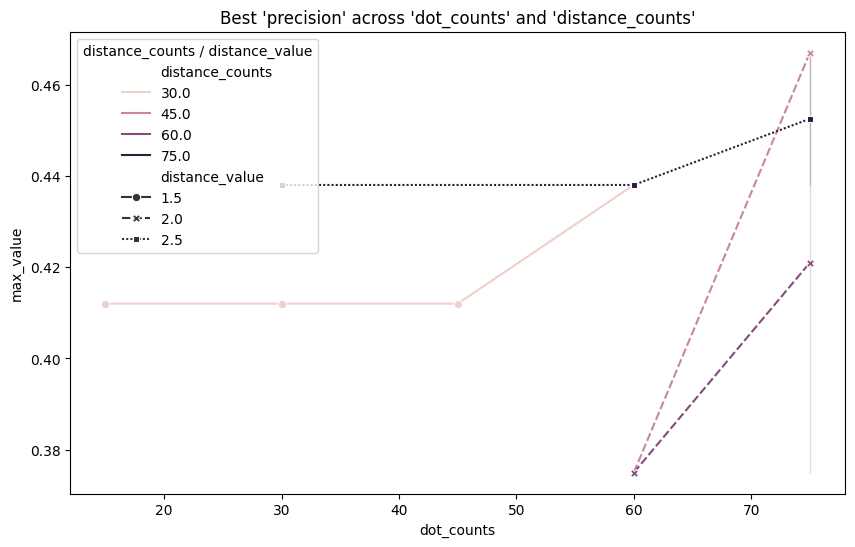

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the results CSV file
results_df = pd.read_csv('parameters_best/best_parameter_combinations.csv')

# Example: Plotting max_value vs. dot_counts for a specific metric
metric = 'precision'
metric_df = results_df[results_df['metric'] == metric]

plt.figure(figsize=(10, 6))
sns.lineplot(data=metric_df, x='dot_counts', y='max_value', hue='distance_counts', style='distance_value', markers=True)
plt.title(f"Best '{metric}' across 'dot_counts' and 'distance_counts'")
plt.xlabel('dot_counts')
plt.ylabel('max_value')
plt.legend(title='distance_counts / distance_value')
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the results CSV file
results_df = pd.read_csv('best_parameter_combinations.csv')

# Example: Plotting max_value vs. dot_counts for a specific metric
metric = 'precision'
metric_df = results_df[results_df['metric'] == metric]

plt.figure(figsize=(10, 6))
sns.lineplot(data=metric_df, x='dot_counts', y='max_value', hue='distance_counts', style='distance_value', markers=True)
plt.title(f"Best '{metric}' across 'dot_counts' and 'distance_counts'")
plt.xlabel('distance_counts')
plt.ylabel('max_value')
plt.legend(title='dot_counts / distance_value')
plt.show()


also I want to then I want to somehow take of each compo dot_value [0.7, 0.8, 0.9] and for each distance_value[1.5, 2, 2.5] to have the best combinatio

In [ ]:
# Define the varying parameters
high_dot_thresholds = [0.7, 0.8, 0.9]
distance_thresholds = [1.5, 2.0, 2.5]
high_dot_counters_threshold = [15, 30, 45, 60, 75, 90]
distance_counters_threshold = [15, 30, 45, 60, 75, 90]

Best combinations for sequence: Apartment_release_clean_seq150_M1292
      time  dot_value  distance_value  dot_counts  distance_counts  \
2268   2.0        0.7             1.5        15.0             15.0   
2269   2.0        0.7             1.5        15.0             30.0   
2270   2.0        0.7             1.5        15.0             45.0   
2271   2.0        0.7             1.5        15.0             60.0   
2272   2.0        0.7             1.5        15.0             75.0   
...    ...        ...             ...         ...              ...   
2587   2.0        0.9             2.5        90.0             30.0   
2588   2.0        0.9             2.5        90.0             45.0   
2589   2.0        0.9             2.5        90.0             60.0   
2590   2.0        0.9             2.5        90.0             75.0   
2591   2.0        0.9             2.5        90.0             90.0   

      model_overall_accuracy  precision  recall  llm_activation_sensitivity  \
2268       